# Tutorial: Marker-based Initial and Final Contact Detection (Leeuwen)

**Author:** KielMAT contributors

## Learning objectives
By the end of this tutorial, you will be able to:

- Load optical motion-capture marker data into a `KielMATRecording` dataclass.
- Apply the Leeuwen coordinate-based **initial contact** (heel strike) and **final contact** (toe-off) detection algorithms.
- Write the detected gait events back into the dataclass with `add_events`.
- Visualize the detected events.

# Leeuwen Initial / Final Contact Detection

This example illustrates the coordinate-based gait-event detection method applied to optical
motion-capture markers. The initial contact detector lives in
[`kielmat.modules.icd._leeuwen`](https://github.com/neurogeriatricskiel/KielMAT/tree/main/kielmat/modules/icd/_leeuwen.py)
and the final contact detector in
[`kielmat.modules.fcd._leeuwen`](https://github.com/neurogeriatricskiel/KielMAT/tree/main/kielmat/modules/fcd/_leeuwen.py).

The method expresses the anterior-posterior (AP) position of a heel marker relative to a pelvis
marker (e.g. sacrum), removing whole-body translation. After a zero-phase Butterworth low-pass
filter, **initial contacts** are the anterior maxima (positive peaks) and **final contacts** are the
posterior minima (negative peaks) of this relative signal. Each `detect()` call processes one leg,
so we run the detectors once per side and combine the results.

#### Reference
[`1`] Zeni, J. A., Richards, J. G., & Higginson, J. S. (2008). Two simple methods for determining gait events during treadmill and overground walking. *Gait & Posture, 27*(4), 710-714. https://doi.org/10.1016/j.gaitpost.2007.07.007

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from kielmat.utils.kielmat_dataclass import KielMATRecording
from kielmat.modules.icd import LeeuwenInitialContactDetection
from kielmat.modules.fcd import LeeuwenFinalContactDetection

## Data Preparation

We load an example BIDS optical motion-capture recording directly from the KielMAT GitHub
repository (`examples/data/`). The `load_bids_marker_recording` helper accepts either a local path
or a URL, and handles two common quirks of raw marker files: a motion `.tsv` with **no header row**,
and a `channels.tsv` that is **missing the `component` column** that `KielMATRecording` requires
(it is derived from the axis suffix of each channel name).

A small `make_synthetic_recording` is also provided as an offline fallback so the notebook always
runs even if the data cannot be downloaded.

In [2]:
AXIS_TO_COMPONENT = {"X": "x", "Y": "y", "Z": "z"}


def load_bids_marker_recording(motion_file, channels_file=None, tracking_system="omc"):
    '''Load a BIDS marker recording (local path or URL) into a KielMATRecording.'''
    motion_file = str(motion_file)
    if channels_file is None:
        # Works for both local paths and URLs ending in ".tsv"
        channels_file = motion_file[:-4] + "_channels.tsv"

    channels = pd.read_csv(channels_file, sep="\t")
    if "component" not in channels.columns:
        channels["component"] = channels["name"].str[-1].map(AXIS_TO_COMPONENT)
    channels = channels[
        ["name", "component", "type", "tracked_point", "units", "sampling_frequency"]
    ]

    col_names = channels["name"].tolist()
    data = pd.read_csv(motion_file, sep="\t")
    if not set(col_names).issubset(data.columns):  # headerless file
        data = pd.read_csv(motion_file, sep="\t", header=None, names=col_names)

    return KielMATRecording(
        data={tracking_system: data}, channels={tracking_system: channels}
    )


def make_synthetic_recording(tracking_system="omc", fs=100.0, duration_s=20.0):
    '''Build a small, reproducible marker recording mimicking the BIDS layout.'''
    t = np.arange(int(fs * duration_s)) / fs
    pelvis_ap = 1.2 * t  # forward progression of the body
    left_rel = 0.4 * np.sin(2 * np.pi * 0.9 * t)
    right_rel = 0.4 * np.sin(2 * np.pi * 0.9 * t + np.pi)  # half-cycle out of phase
    z = np.zeros_like(t)

    data = pd.DataFrame(
        {
            "LHEE_PosX": z, "LHEE_PosY": pelvis_ap + left_rel, "LHEE_PosZ": z + 0.05,
            "RHEE_PosX": z, "RHEE_PosY": pelvis_ap + right_rel, "RHEE_PosZ": z + 0.05,
            "SACR_PosX": z, "SACR_PosY": pelvis_ap, "SACR_PosZ": z + 1.0,
        }
    )
    names = list(data.columns)
    channels = pd.DataFrame(
        {
            "name": names,
            "component": [AXIS_TO_COMPONENT[n[-1]] for n in names],
            "type": ["POS"] * len(names),
            "tracked_point": ["left_heel"] * 3 + ["right_heel"] * 3 + ["pelvis"] * 3,
            "units": ["m"] * len(names),
            "sampling_frequency": [fs] * len(names),
        }
    )
    return KielMATRecording(
        data={tracking_system: data}, channels={tracking_system: channels}
    )

In [6]:
tracking_system = "omc"

# Example BIDS marker recording hosted in the KielMAT repository
DATA_URL = (
    "https://raw.githubusercontent.com/neurogeriatricskiel/KielMAT/"
    "icfcleeuwen/examples/data/sub-S1_task-CS.tsv"
)

# Load the data into the KielMAT dataclass
try:
    recording = load_bids_marker_recording(DATA_URL, tracking_system=tracking_system)
    print("Loaded example data from GitHub.")
except Exception as err:
    print(f"Could not download data ({err}); using synthetic data instead.")
    recording = make_synthetic_recording(tracking_system)

# Validate and read the sampling frequency directly from the channels
print(recording.validate_channels())
sampling_freq_Hz = float(
    recording.channels[tracking_system]["sampling_frequency"].iloc[0]
)
print("Sampling frequency:", sampling_freq_Hz, "Hz")
recording.data[tracking_system].head()

Loaded example data from GitHub.
All channel dataframes are valid.
Sampling frequency: 100.0 Hz


,LHEE_PosX,LHEE_PosY,LHEE_PosZ,RHEE_PosX,RHEE_PosY,RHEE_PosZ,SACR_PosX,SACR_PosY,SACR_PosZ
0,0.414353,0.516800,0.063445,0.524544,0.907456,0.061067,0.475568,0.627096,1.031941
1,0.414878,0.503252,0.063728,0.527780,0.931996,0.058845,0.476747,0.626934,1.029352
2,0.415394,0.489616,0.064087,0.530661,0.954755,0.057553,0.478116,0.627030,1.026404
3,0.415783,0.476130,0.064512,0.532323,0.975635,0.057313,0.479570,0.627214,1.023384
4,0.416100,0.462771,0.065034,0.532508,0.994115,0.057859,0.481061,0.627491,1.020412


## Applying the Leeuwen Detectors

We run both the initial- and final-contact detectors once per leg, passing the heel marker column
and the shared pelvis (sacrum) reference column. The anterior-posterior axis for these markers is
`PosY`. The detected events are written back into the dataclass with `recording.add_events`, which
accumulates them per tracking system.

In [4]:
legs = {"left": "LHEE_PosY", "right": "RHEE_PosY"}
reference_col = "SACR_PosY"

for side, heel_col in legs.items():
    icd = LeeuwenInitialContactDetection().detect(
        data=recording.data[tracking_system],
        sampling_freq_Hz=sampling_freq_Hz,
        heel_col_name=heel_col,
        reference_col_name=reference_col,
        side=side,
        tracking_system=tracking_system,
    )
    fcd = LeeuwenFinalContactDetection().detect(
        data=recording.data[tracking_system],
        sampling_freq_Hz=sampling_freq_Hz,
        heel_col_name=heel_col,
        reference_col_name=reference_col,
        side=side,
        tracking_system=tracking_system,
    )
    recording.add_events(tracking_system, icd.initial_contacts_)
    recording.add_events(tracking_system, fcd.final_contacts_)

# The events now live in the dataclass
events = (
    recording.events[tracking_system]
    .sort_values("onset")
    .reset_index(drop=True)
)
print(events["event_type"].value_counts())
events.head(8)

event_type
initial contact    36
final contact      36
Name: count, dtype: int64


,onset,duration,event_type,side,tracking_system
0,0.28,0,initial contact,left,omc
1,0.28,0,final contact,right,omc
2,0.83,0,initial contact,right,omc
3,0.83,0,final contact,left,omc
4,1.39,0,initial contact,left,omc
5,1.39,0,final contact,right,omc
6,1.94,0,final contact,left,omc
7,1.94,0,initial contact,right,omc


## Visualization of the Detected Events

We plot the pelvis-referenced left heel signal with the detected initial and final contacts.
Initial contacts fall on the anterior maxima, final contacts on the posterior minima.

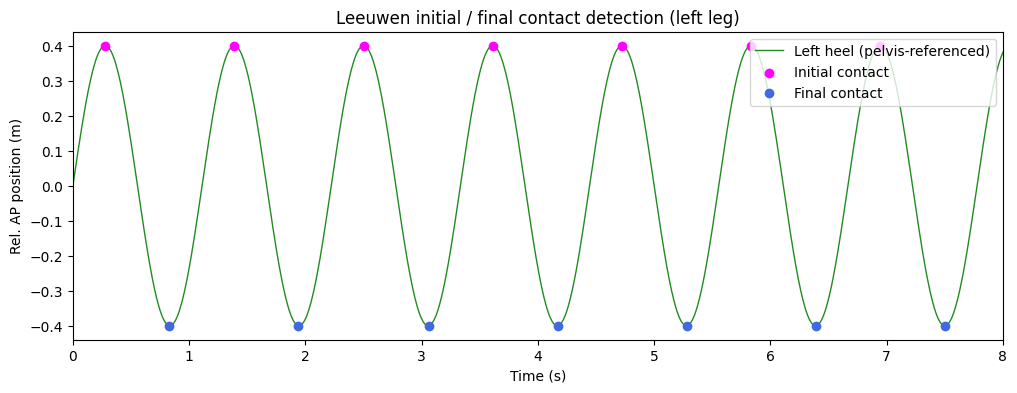

In [5]:
data = recording.data[tracking_system]
time = np.arange(len(data)) / sampling_freq_Hz

# Recompute the pelvis-referenced left heel signal (as used internally by the detectors)
rel_left = (data["LHEE_PosY"] - data["SACR_PosY"]).to_numpy()
rel_left = rel_left - rel_left.mean()

ev_left = events[events["side"] == "left"]
ic_left = ev_left[ev_left["event_type"] == "initial contact"]["onset"]
fc_left = ev_left[ev_left["event_type"] == "final contact"]["onset"]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time, rel_left, color="forestgreen", lw=1.0, label="Left heel (pelvis-referenced)")
ax.scatter(ic_left, np.interp(ic_left, time, rel_left),
           color="magenta", zorder=3, label="Initial contact")
ax.scatter(fc_left, np.interp(fc_left, time, rel_left),
           color="royalblue", zorder=3, label="Final contact")
ax.set_xlim(0, 8)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Rel. AP position (m)")
ax.set_title("Leeuwen initial / final contact detection (left leg)")
ax.legend(loc="upper right")
plt.show()